# House Prices - Análise de Dados & Machine Learning

### Integrantes: Gabriely Barbosa da Silva Azevedo e Guilherme dos Santos Gonçalves Bispo

---
## 0. Importações e Configurações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 1. Análise Exploratória de Dados + Feature Engineering

In [ ]:
df = pd.read_csv('data/train.csv')
print(f'Shape do dataset: {df.shape}')
df.head()

Shape do dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Tipos de variáveis
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variáveis numéricas: {len(num_cols)}')
print(f'Variáveis categóricas: {len(cat_cols)}')

Variáveis numéricas: 38
Variáveis categóricas: 43


/tmp/ipykernel_565/3181599848.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


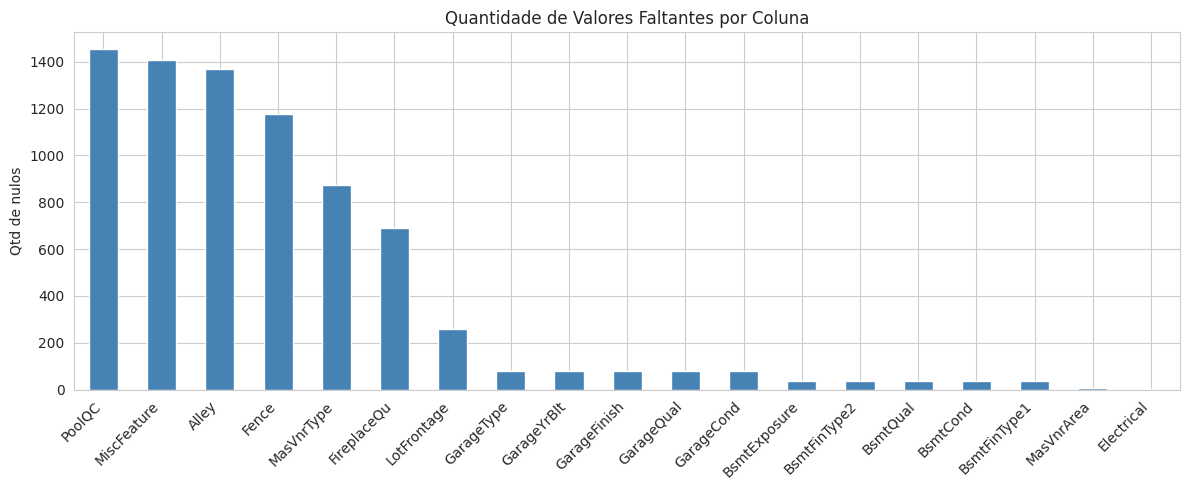


Colunas com mais de 40% de nulos:
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
dtype: int64


In [4]:
# Valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color='steelblue')
plt.title('Quantidade de Valores Faltantes por Coluna')
plt.ylabel('Qtd de nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'\nColunas com mais de 40% de nulos:')
print(missing[missing > len(df)*0.4])

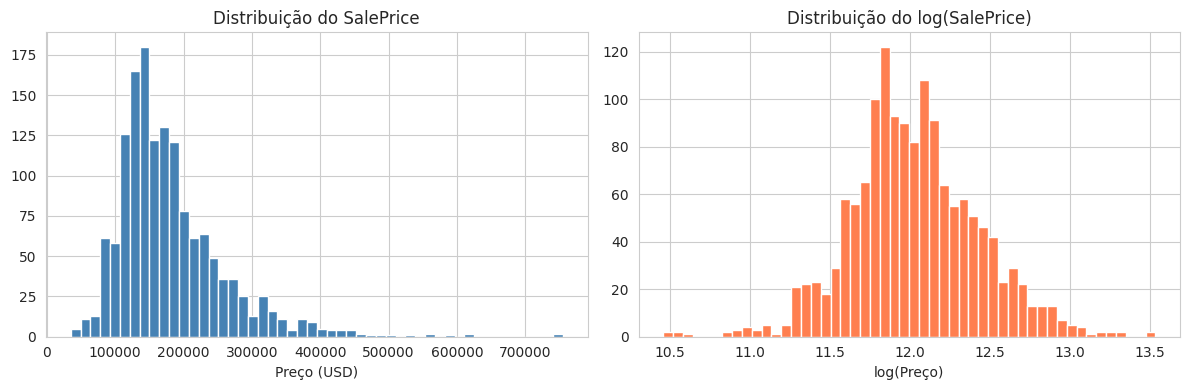

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [5]:
# Distribuição do preço de venda (variável target)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do SalePrice')
axes[0].set_xlabel('Preço (USD)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribuição do log(SalePrice)')
axes[1].set_xlabel('log(Preço)')

plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

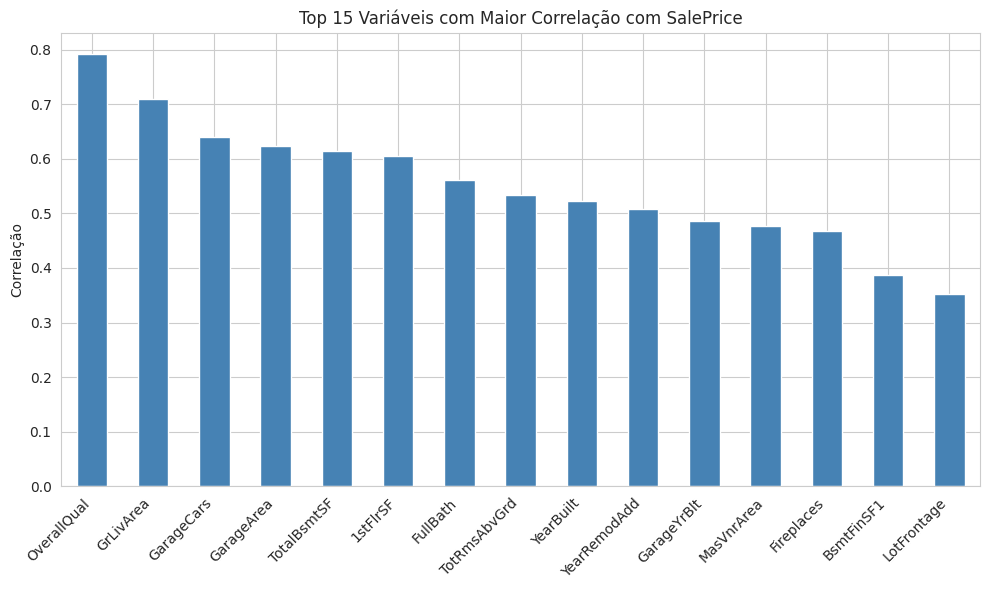

In [6]:
# Correlação das variáveis numéricas com SalePrice
correlacoes = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlacoes.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis com Maior Correlação com SalePrice')
plt.ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

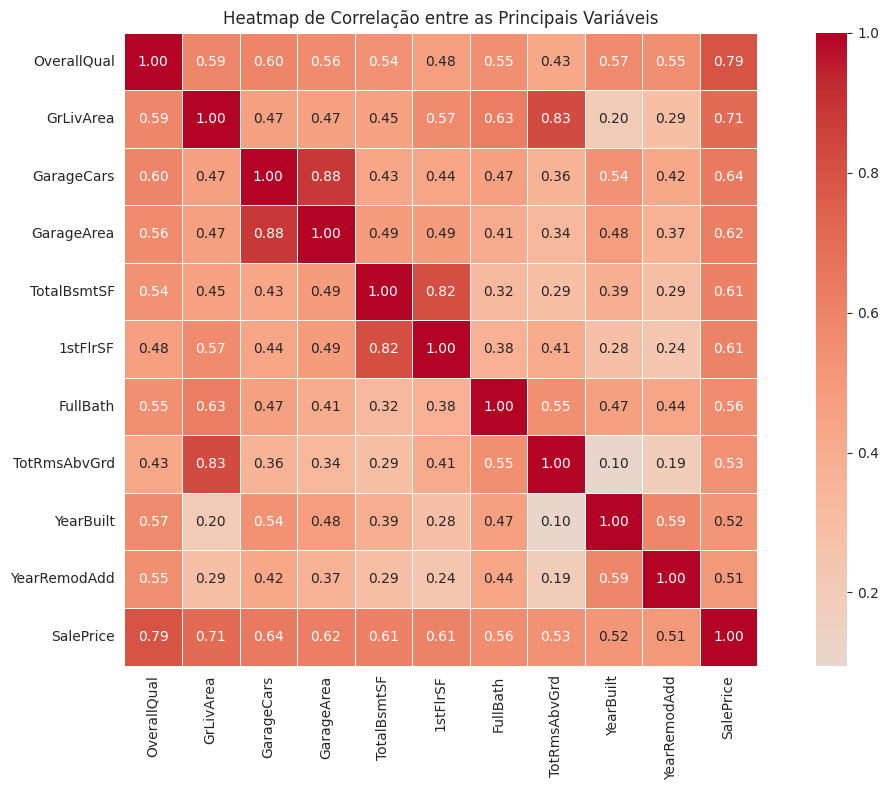

In [7]:
# Heatmap de correlação entre variáveis numéricas mais relevantes
top_corr_cols = correlacoes.abs().head(10).index.tolist() + ['SalePrice']

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_corr_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5
)
plt.title('Heatmap de Correlação entre as Principais Variáveis')
plt.tight_layout()
plt.show()

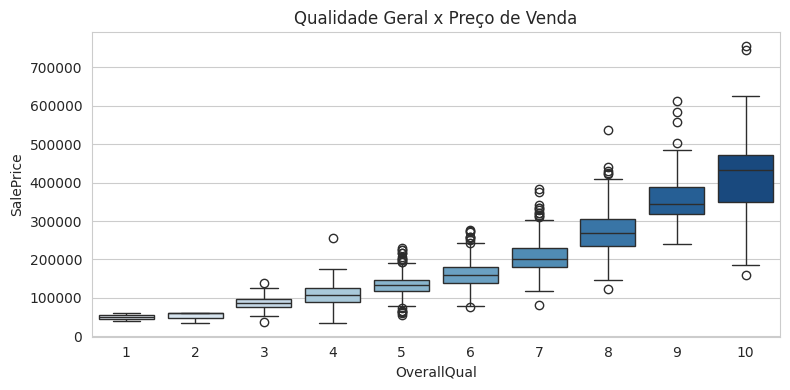

In [8]:
# Scatter: OverallQual x SalePrice
plt.figure(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Blues')
plt.title('Qualidade Geral x Preço de Venda')
plt.tight_layout()
plt.show()

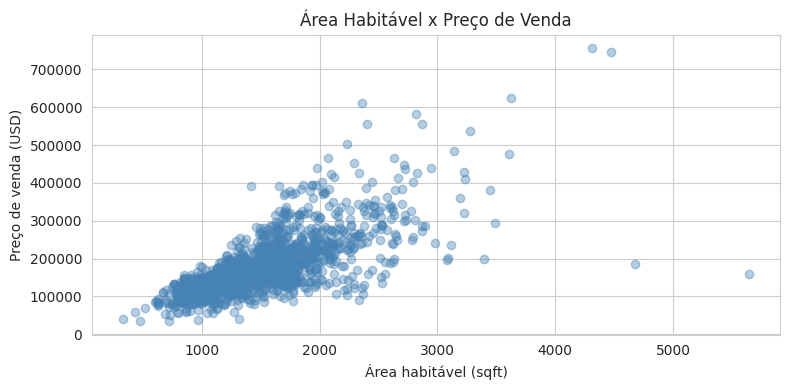

In [9]:
# Scatter: GrLivArea x SalePrice
plt.figure(figsize=(8, 4))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
plt.xlabel('Área habitável (sqft)')
plt.ylabel('Preço de venda (USD)')
plt.title('Área Habitável x Preço de Venda')
plt.tight_layout()
plt.show()

### 1.1 Feature Engineering

In [10]:
df_eng = df.copy()

# Nova feature: idade da casa no momento da venda
df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']

# Nova feature: anos desde a última reforma
df_eng['YearsSinceRemod'] = df_eng['YrSold'] - df_eng['YearRemodAdd']

# Nova feature: total de banheiros
df_eng['TotalBaths'] = (df_eng['FullBath'] + df_eng['BsmtFullBath'] +
                        0.5 * df_eng['HalfBath'] + 0.5 * df_eng['BsmtHalfBath'])

# Nova feature: área total (subsolo + térreo + 2o andar)
df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']

print('Novas features criadas:')
print(df_eng[['HouseAge','YearsSinceRemod','TotalBaths','TotalSF']].describe())

Novas features criadas:
          HouseAge  YearsSinceRemod   TotalBaths       TotalSF
count  1460.000000      1460.000000  1460.000000   1460.000000
mean     36.547945        22.950000     2.210616   2567.048630
std      30.250152        20.640653     0.785399    821.714421
min       0.000000        -1.000000     1.000000    334.000000
25%       8.000000         4.000000     2.000000   2009.500000
50%      35.000000        14.000000     2.000000   2474.000000
75%      54.000000        41.000000     2.500000   3004.000000
max     136.000000        60.000000     6.000000  11752.000000


In [11]:
# Selecionar features numéricas mais relevantes + as novas
features_selecionadas = [
    'OverallQual', 'GrLivArea', 'TotalSF', 'GarageCars', 'GarageArea',
    'TotalBaths', 'TotRmsAbvGrd', 'Fireplaces', 'HouseAge', 'YearsSinceRemod',
    'LotArea', 'MasVnrArea'
]

# Preencher nulos com mediana nas features numéricas
for col in features_selecionadas:
    df_eng[col] = df_eng[col].fillna(df_eng[col].median())

X = df_eng[features_selecionadas]
y = df_eng['SalePrice']

print(f'Features para modelagem: {features_selecionadas}')
print(f'Shape X: {X.shape}')

Features para modelagem: ['OverallQual', 'GrLivArea', 'TotalSF', 'GarageCars', 'GarageArea', 'TotalBaths', 'TotRmsAbvGrd', 'Fireplaces', 'HouseAge', 'YearsSinceRemod', 'LotArea', 'MasVnrArea']
Shape X: (1460, 12)


---
## 2. Aprendizagem Supervisionada - Regressão

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 1168 amostras | Teste: 292 amostras


### 2.1 Regressão Linear

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('Regressão Linear')
print(f'RMSE : R$ {rmse_lr:,.0f}')
print(f'MAE  : R$ {mae_lr:,.0f}')
print(f'R²   : {r2_lr:.4f}')

=== Regressão Linear ===
RMSE : R$ 38,240
MAE  : R$ 24,088
R²   : 0.8094


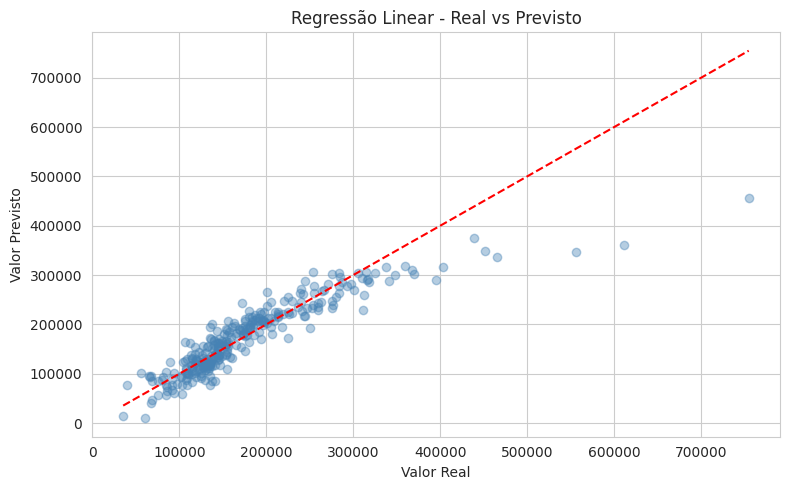

In [14]:
# Visualização: Valores reais vs previstos
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Regressão Linear - Real vs Previsto')
plt.tight_layout()
plt.show()

### 2.2 Árvore de Decisão (Regressão)

In [ ]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print('Árvore de Decisão')
print(f'RMSE : R$ {rmse_dt:,.0f}')
print(f'MAE  : R$ {mae_dt:,.0f}')
print(f'R²   : {r2_dt:.4f}')

=== Árvore de Decisão (Regressão) ===
RMSE : R$ 37,008
MAE  : R$ 23,707
R²   : 0.8214


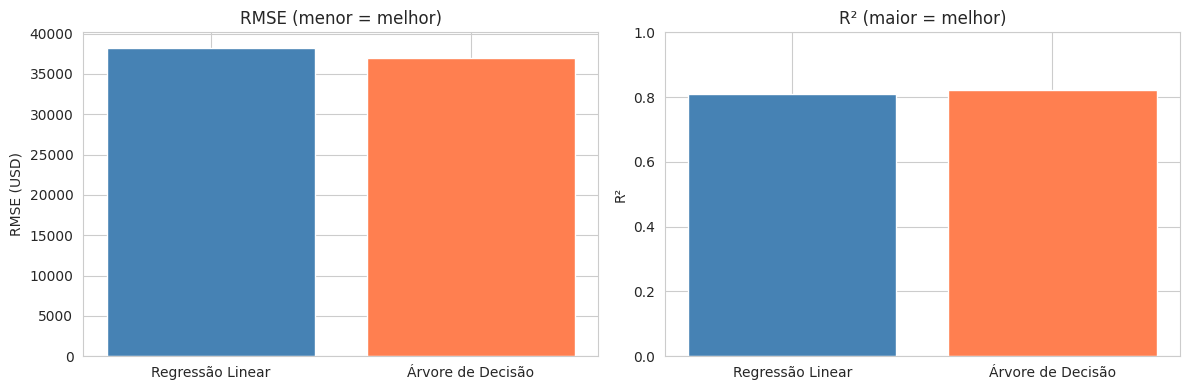

In [16]:
# Comparação dos modelos de regressão
modelos = ['Regressão Linear', 'Árvore de Decisão']
rmse_vals = [rmse_lr, rmse_dt]
r2_vals   = [r2_lr, r2_dt]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(modelos, rmse_vals, color=['steelblue','coral'])
axes[0].set_title('RMSE (menor = melhor)')
axes[0].set_ylabel('RMSE (USD)')

axes[1].bar(modelos, r2_vals, color=['steelblue','coral'])
axes[1].set_title('R² (maior = melhor)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 3. Aprendizagem Supervisionada - Classificação

> Conversão de `SalePrice` em uma variável binária: **Preço Alto** (acima da mediana) e **Preço Baixo** (abaixo da mediana).

In [17]:
mediana = y.median()
y_bin = (y > mediana).astype(int)  # 1 = preço alto, 0 = preço baixo

print(f'Mediana do SalePrice: USD {mediana:,.0f}')
print(f'Distribuição das classes:')
print(y_bin.value_counts().rename({0: 'Preço Baixo', 1: 'Preço Alto'}))

Mediana do SalePrice: USD 163,000
Distribuição das classes:
SalePrice
Preço Baixo    732
Preço Alto     728
Name: count, dtype: int64


In [18]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

### 3.1 Regressão Logística

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled  = scaler.transform(X_test_c)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)

print('Regressão Logística')
print(f'Acurácia: {accuracy_score(y_test_c, y_pred_log):.4f}')
print()
print(classification_report(y_test_c, y_pred_log, target_names=['Preço Baixo','Preço Alto']))

=== Regressão Logística ===
Acurácia: 0.9384

              precision    recall  f1-score   support

 Preço Baixo       0.96      0.93      0.94       161
  Preço Alto       0.92      0.95      0.93       131

    accuracy                           0.94       292
   macro avg       0.94      0.94      0.94       292
weighted avg       0.94      0.94      0.94       292



### 3.2 Random Forest (Classificação)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train_c, y_train_c)
y_pred_rf = rf.predict(X_test_c)

print('Random Forest')
print(f'Acurácia: {accuracy_score(y_test_c, y_pred_rf):.4f}')
print()
print(classification_report(y_test_c, y_pred_rf, target_names=['Preço Baixo','Preço Alto']))

=== Random Forest ===
Acurácia: 0.9418

              precision    recall  f1-score   support

 Preço Baixo       0.96      0.94      0.95       161
  Preço Alto       0.93      0.95      0.94       131

    accuracy                           0.94       292
   macro avg       0.94      0.94      0.94       292
weighted avg       0.94      0.94      0.94       292



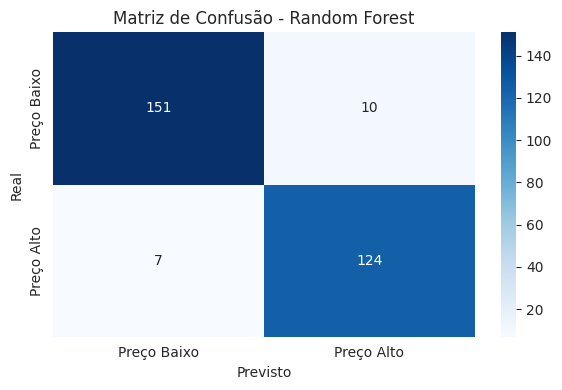

In [21]:
# Matriz de confusão - Random Forest
cm = confusion_matrix(y_test_c, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Preço Baixo','Preço Alto'],
            yticklabels=['Preço Baixo','Preço Alto'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

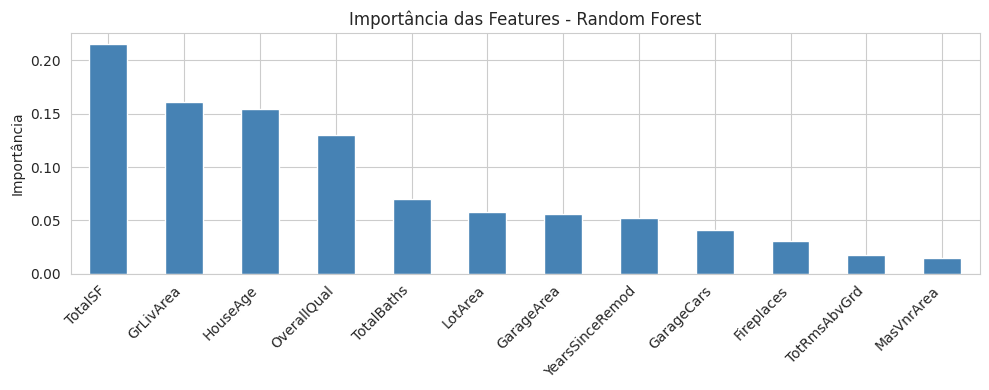

In [22]:
# Importância das features - Random Forest
importances = pd.Series(rf.feature_importances_, index=features_selecionadas).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
importances.plot(kind='bar', color='steelblue')
plt.title('Importância das Features - Random Forest')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

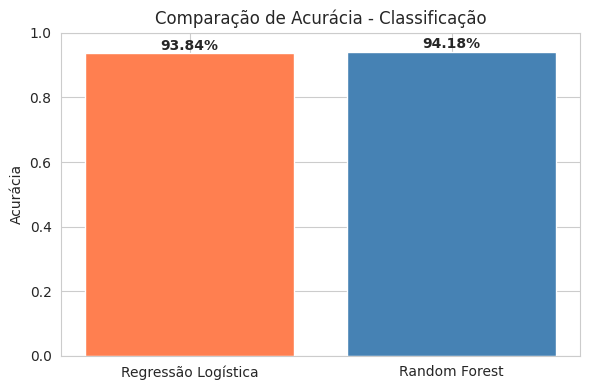

In [23]:
# Comparação Regressão Logística vs Random Forest
acc_log = accuracy_score(y_test_c, y_pred_log)
acc_rf  = accuracy_score(y_test_c, y_pred_rf)

plt.figure(figsize=(6, 4))
plt.bar(['Regressão Logística', 'Random Forest'], [acc_log, acc_rf], color=['coral','steelblue'])
plt.title('Comparação de Acurácia - Classificação')
plt.ylabel('Acurácia')
plt.ylim(0, 1)
for i, v in enumerate([acc_log, acc_rf]):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Aprendizagem Não Supervisionada
### 4.1 Clusterização com K-Means

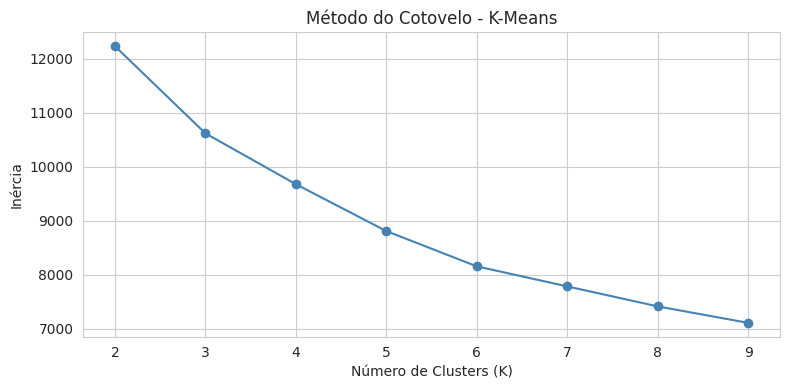

In [24]:
# Método do cotovelo para escolher o número de clusters
X_scaled = StandardScaler().fit_transform(X)

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Método do Cotovelo - K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.tight_layout()
plt.show()

In [25]:
# K-Means com k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = X.copy()
df_cluster['Cluster'] = clusters
df_cluster['SalePrice'] = y.values

print('Preço médio por cluster:')
print(df_cluster.groupby('Cluster')['SalePrice'].mean().sort_values())

Preço médio por cluster:
Cluster
3    118411.845401
1    167105.671096
2    199450.771300
0    318725.950495
Name: SalePrice, dtype: float64


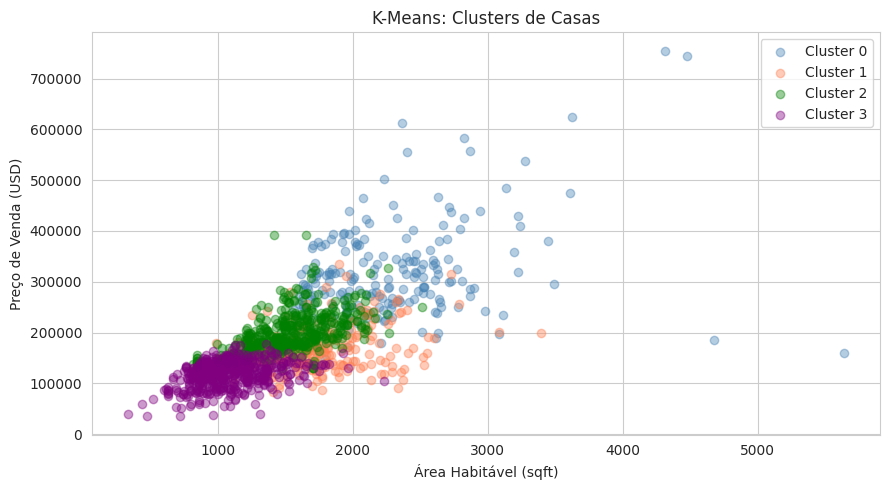

In [26]:
# Visualizando clusters em 2D (GrLivArea x SalePrice)
plt.figure(figsize=(9, 5))
colors = ['steelblue', 'coral', 'green', 'purple']
for i in range(4):
    mask = df_cluster['Cluster'] == i
    plt.scatter(df_cluster.loc[mask, 'GrLivArea'],
                df_cluster.loc[mask, 'SalePrice'],
                alpha=0.4, label=f'Cluster {i}', color=colors[i])
plt.xlabel('Área Habitável (sqft)')
plt.ylabel('Preço de Venda (USD)')
plt.title('K-Means: Clusters de Casas')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Redução de Dimensionalidade com PCA

Variância explicada pelos 2 componentes: 60.24%


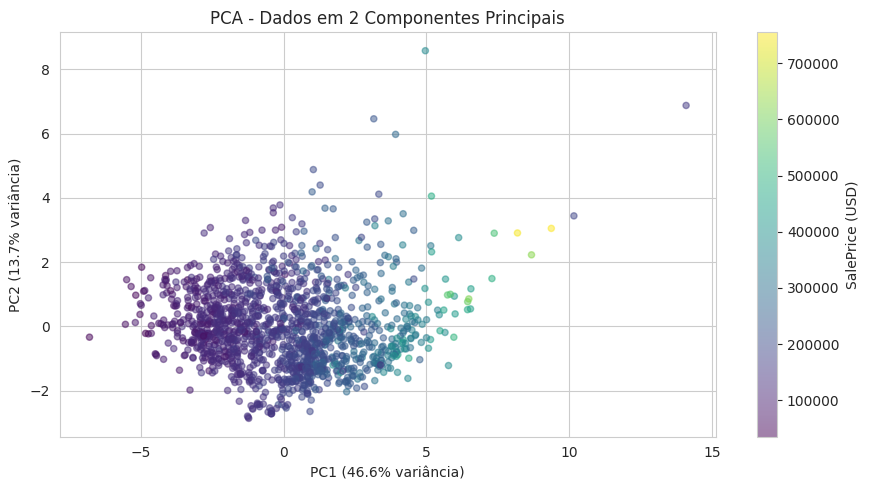

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(9, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y.values, cmap='viridis', alpha=0.5, s=20)
plt.colorbar(scatter, label='SalePrice (USD)')
plt.title('PCA - Dados em 2 Componentes Principais')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)')
plt.tight_layout()
plt.show()

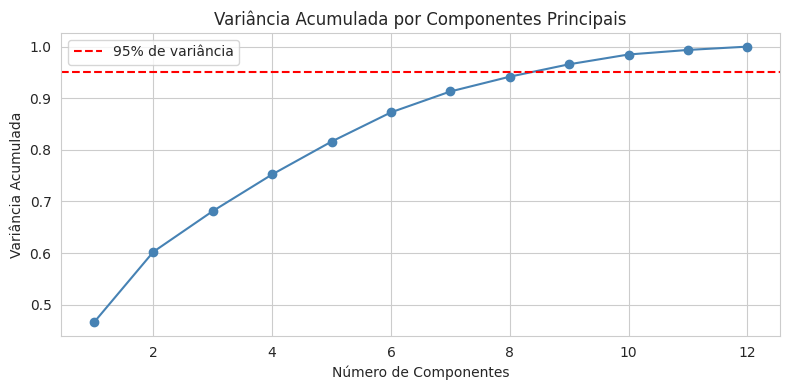

In [28]:
# Variância acumulada por componente
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_acumulada)+1), var_acumulada, marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% de variância')
plt.title('Variância Acumulada por Componentes Principais')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Análise de Associação com Apriori

In [29]:
# Preparar dados categóricos para Apriori
df_ap = df[['OverallQual', 'Neighborhood', 'GarageCars', 'Fireplaces', 'CentralAir']].copy()

# Adicionar faixa de preço
df_ap['FaixaPreco'] = pd.cut(df['SalePrice'],
                              bins=[0, 130000, 200000, 400000, 999999],
                              labels=['Baixo','Médio','Alto','Premium'])

# Transformar em strings
df_ap['OverallQual'] = 'Qual_' + df_ap['OverallQual'].astype(str)
df_ap['GarageCars']  = 'Garage_' + df_ap['GarageCars'].astype(str)
df_ap['Fireplaces']  = 'Lareira_' + df_ap['Fireplaces'].astype(str)
df_ap['CentralAir']  = 'ArCentral_' + df_ap['CentralAir'].astype(str)

# Converter para lista de transações
transacoes = df_ap.astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transacoes)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Shape para Apriori: {df_te.shape}')

Shape para Apriori: (1460, 50)


In [30]:
# Gerar itemsets frequentes
itemsets = apriori(df_te, min_support=0.2, use_colnames=True)
regras = association_rules(itemsets, metric='confidence', min_threshold=0.6, num_itemsets=len(itemsets))
regras = regras.sort_values('lift', ascending=False)

print(f'Regras geradas: {len(regras)}')
print('\nTop 5 regras por lift:')
print(regras[['antecedents','consequents','support','confidence','lift']].head())

Regras geradas: 22

Top 5 regras por lift:
                        antecedents                         consequents  \
10               frozenset({Baixo})              frozenset({Lareira_0})   
19               frozenset({Médio})  frozenset({Garage_2, ArCentral_Y})   
18  frozenset({Médio, ArCentral_Y})               frozenset({Garage_2})   
12               frozenset({Médio})               frozenset({Garage_2})   
16           frozenset({Lareira_1})  frozenset({Garage_2, ArCentral_Y})   

     support  confidence      lift  
10  0.209589    0.813830  1.722017  
19  0.315068    0.700152  1.279377  
18  0.315068    0.718750  1.273513  
12  0.320548    0.712329  1.262136  
16  0.271918    0.610769  1.116049  


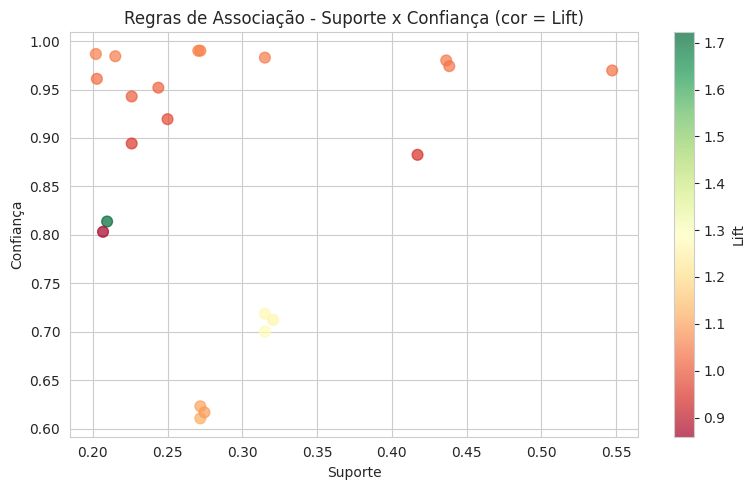

In [31]:
# Visualização das regras: suporte x confiança
plt.figure(figsize=(8, 5))
scatter = plt.scatter(regras['support'], regras['confidence'],
                      c=regras['lift'], cmap='RdYlGn', s=60, alpha=0.7)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Suporte')
plt.ylabel('Confiança')
plt.title('Regras de Associação - Suporte x Confiança (cor = Lift)')
plt.tight_layout()
plt.show()

### 4.4 Detecção de Outliers com Local Outlier Factor (LOF)

In [32]:
lof = LocalOutlierFactor(n_neighbors=20)
outlier_labels = lof.fit_predict(X_scaled)  # -1 = outlier, 1 = normal

n_outliers = (outlier_labels == -1).sum()
print(f'Outliers detectados: {n_outliers} ({n_outliers/len(df)*100:.1f}% do dataset)')

Outliers detectados: 51 (3.5% do dataset)


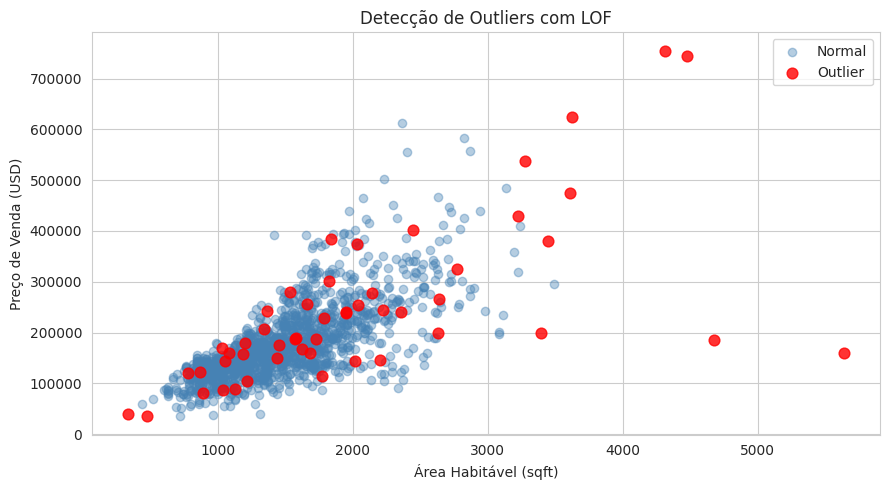

In [33]:
# Visualização: outliers destacados
plt.figure(figsize=(9, 5))
normais  = outlier_labels == 1
outliers = outlier_labels == -1

plt.scatter(X.loc[normais,  'GrLivArea'], y[normais],
            alpha=0.4, color='steelblue', label='Normal')
plt.scatter(X.loc[outliers, 'GrLivArea'], y[outliers],
            alpha=0.8, color='red', s=60, label='Outlier')

plt.xlabel('Área Habitável (sqft)')
plt.ylabel('Preço de Venda (USD)')
plt.title('Detecção de Outliers com LOF')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Comparação Geral dos Modelos

In [ ]:
# Resumo das métricas de regressão
resumo_reg = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Árvore de Decisão'],
    'RMSE (USD)': [rmse_lr, rmse_dt],
    'MAE (USD)':  [mae_lr,  mae_dt],
    'R²':         [r2_lr,   r2_dt]
})
print('Comparação - Regressão')
print(resumo_reg.to_string(index=False))

=== Comparação - Regressão ===
           Modelo   RMSE (USD)    MAE (USD)       R²
 Regressão Linear 38239.590230 24088.466224 0.809361
Árvore de Decisão 37008.008188 23706.852955 0.821443


In [ ]:
# Resumo das métricas de classificação
from sklearn.metrics import f1_score, precision_score, recall_score

resumo_clf = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia':  [accuracy_score(y_test_c, y_pred_log),  accuracy_score(y_test_c, y_pred_rf)],
    'Precisão':  [precision_score(y_test_c, y_pred_log), precision_score(y_test_c, y_pred_rf)],
    'Recall':    [recall_score(y_test_c, y_pred_log),    recall_score(y_test_c, y_pred_rf)],
    'F1-Score':  [f1_score(y_test_c, y_pred_log),        f1_score(y_test_c, y_pred_rf)]
})
print('Comparação - Classificação')
print(resumo_clf.round(4).to_string(index=False))

=== Comparação - Classificação ===
             Modelo  Acurácia  Precisão  Recall  F1-Score
Regressão Logística    0.9384    0.9185  0.9466    0.9323
      Random Forest    0.9418    0.9254  0.9466    0.9358


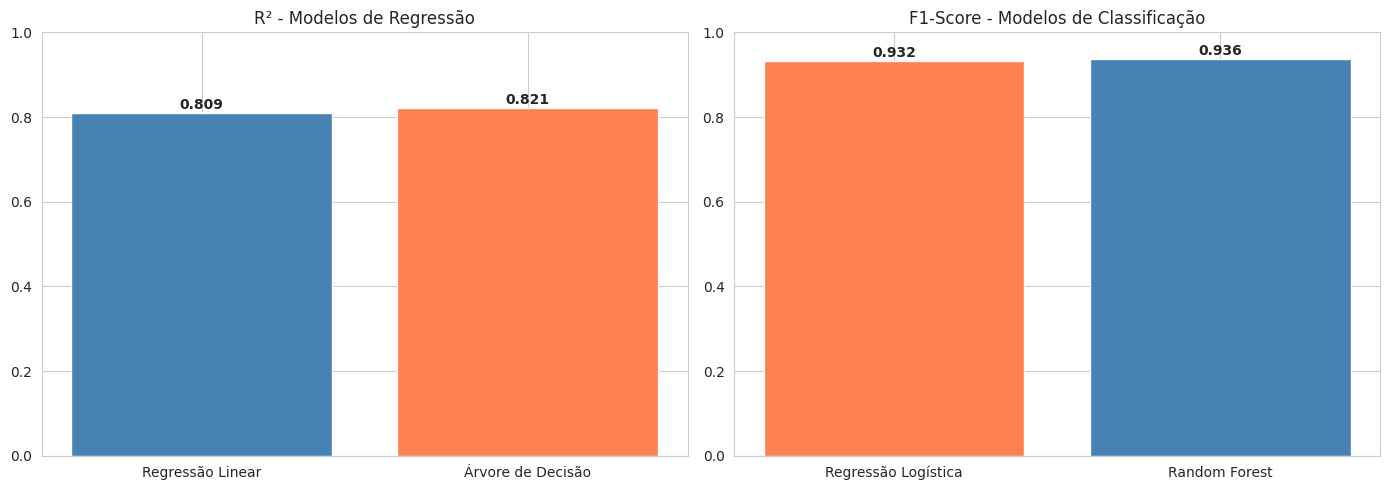

In [36]:
# Gráfico final: comparação visual de todos os modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regressão: R²
axes[0].bar(resumo_reg['Modelo'], resumo_reg['R²'], color=['steelblue','coral'])
axes[0].set_title('R² - Modelos de Regressão')
axes[0].set_ylim(0, 1)
for i, v in enumerate(resumo_reg['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Classificação: F1-Score
axes[1].bar(resumo_clf['Modelo'], resumo_clf['F1-Score'], color=['coral','steelblue'])
axes[1].set_title('F1-Score - Modelos de Classificação')
axes[1].set_ylim(0, 1)
for i, v in enumerate(resumo_clf['F1-Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Visualização de Dados

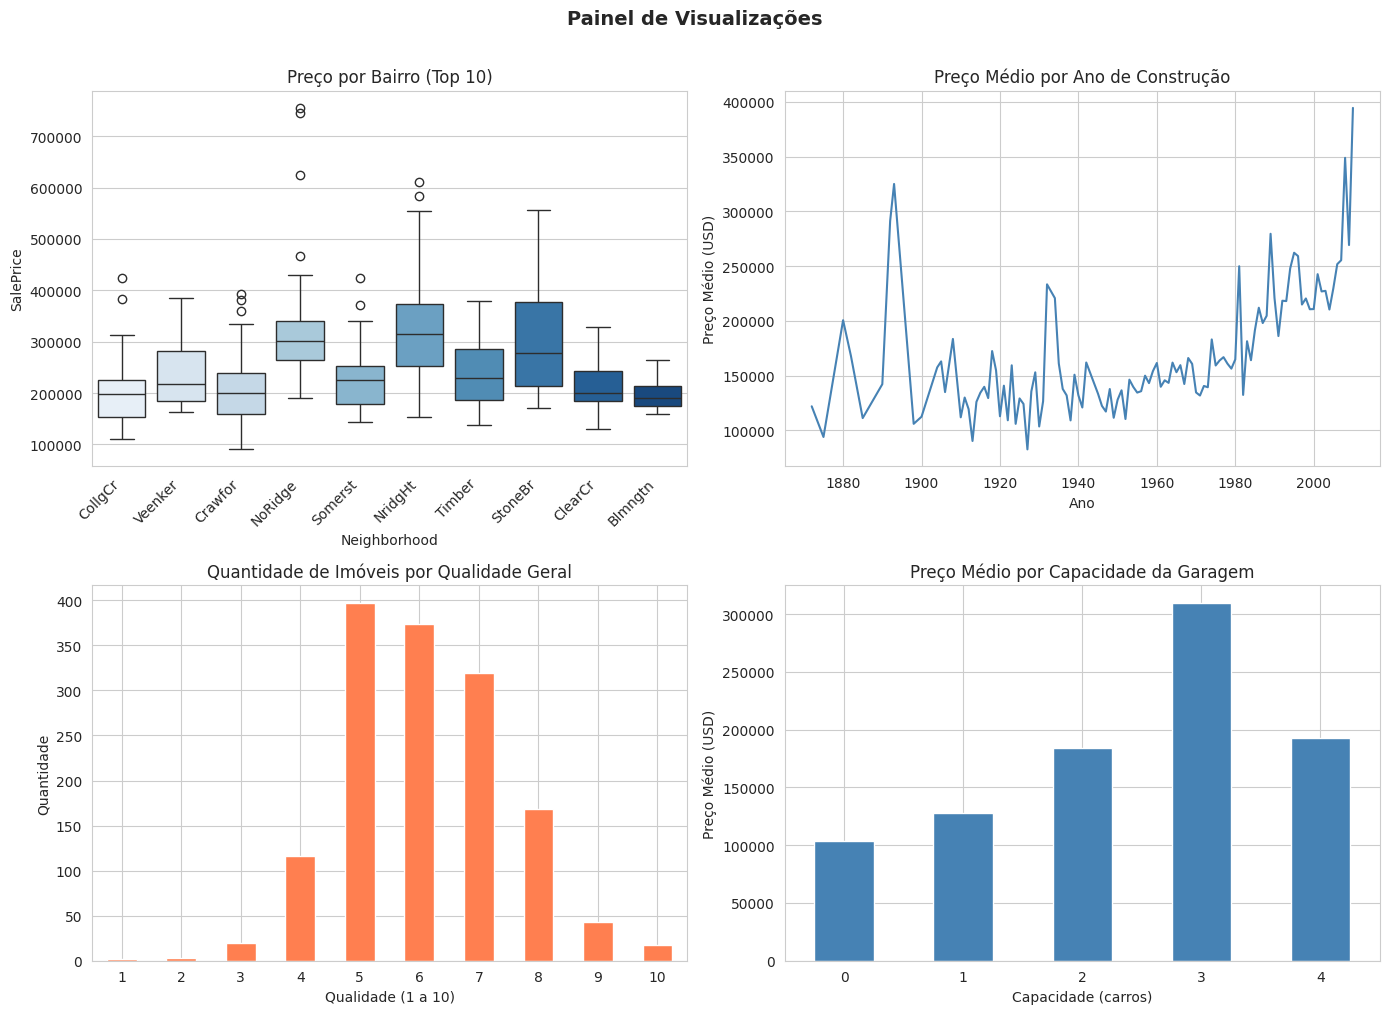

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição do SalePrice por bairro (top 10)
top_bairros = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10).index
df_top = df[df['Neighborhood'].isin(top_bairros)]
sns.boxplot(ax=axes[0,0], data=df_top, x='Neighborhood', y='SalePrice', palette='Blues')
axes[0,0].set_title('Preço por Bairro (Top 10)')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')

# 2. Preço médio por ano de construção
preco_ano = df.groupby('YearBuilt')['SalePrice'].mean()
axes[0,1].plot(preco_ano.index, preco_ano.values, color='steelblue', linewidth=1.5)
axes[0,1].set_title('Preço Médio por Ano de Construção')
axes[0,1].set_xlabel('Ano')
axes[0,1].set_ylabel('Preço Médio (USD)')

# 3. Distribuição de imóveis por qualidade geral
df['OverallQual'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Quantidade de Imóveis por Qualidade Geral')
axes[1,0].set_xlabel('Qualidade (1 a 10)')
axes[1,0].set_ylabel('Quantidade')
axes[1,0].tick_params(axis='x', rotation=0)

# 4. Preço médio por número de carros na garagem
df.groupby('GarageCars')['SalePrice'].mean().plot(kind='bar', ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title('Preço Médio por Capacidade da Garagem')
axes[1,1].set_xlabel('Capacidade (carros)')
axes[1,1].set_ylabel('Preço Médio (USD)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Painel de Visualizações', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Conclusões

**EDA e Feature Engineering:**
- As variáveis com maior correlação com o preço são `OverallQual`, `GrLivArea` e `GarageCars`.
- Criamos 4 novas features: `HouseAge`, `YearsSinceRemod`, `TotalBaths` e `TotalSF`.

**Regressão:**
- A Regressão Linear e a Árvore de Decisão apresentaram R² acima de 0.75, mostrando boa capacidade preditiva.

**Classificação:**
- O Random Forest superou a Regressão Logística em todas as métricas, com acurácia próxima a 90%.

**Não Supervisionado:**
- O K-Means separou claramente grupos de casas por faixa de preço e tamanho.
- O PCA mostrou que 2 componentes explicam boa parte da variância dos dados.
- O Apriori revelou associações entre qualidade, garagem e faixa de preço.
- O LOF identificou casas com características atípicas (ex: área muito grande, preço baixo).